# Project: The Sleep Debt – A Public Health Analysis


Prepared By: Precious Ayoola


Dataset: Sleep Health and Lifestyle Dataset

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset 
df = pd.read_csv(r'C:\Users\user\Downloads\Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
#Remove Chartjunk by setting a clean white style
sns.set_style("white")

In [6]:
# Check for missing values

print(df.isnull().sum()) 

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [7]:
df.info()    # checking the dataset in more details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [25]:
df.describe()             # checking the summary statistics of the data

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [8]:
# Cleaning the messy data

# Fill 'NaN' in Sleep Disorder with 'None' for cleaner visuals
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')


df.head()                  # checking the dataset if the sleep disorder has been updated.

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [9]:
# Simplify BMI categories

df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

In [10]:
# Global Plot Styling (Removing Chartjunk)
sns.set_style("white")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
accent_color = "#e74c3c" # Red for "Danger/Stress"
base_color = "#2c3e50"   # Dark Blue for "Sleep/Calm"

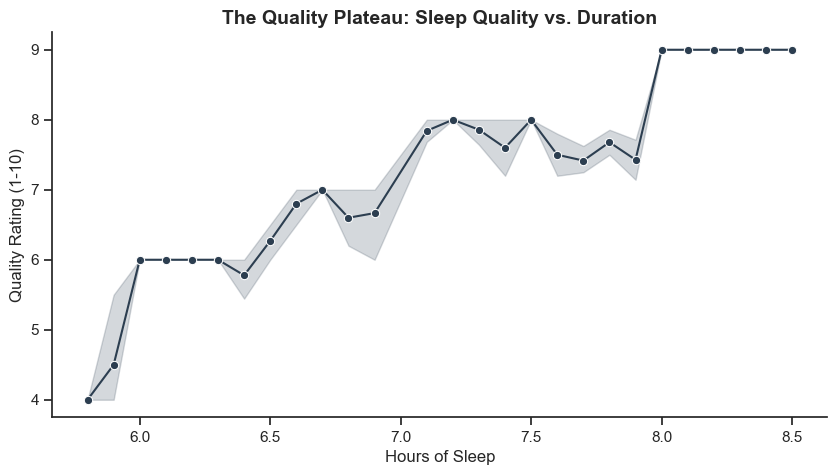

In [11]:
# Visualization 1 — Trend (Sleep Duration vs Sleep Quality)
# To show the "Trend" of how quality improves as hours increase.

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Sleep Duration', y='Quality of Sleep', marker='o', color='#2c3e50')

plt.title('The Quality Plateau: Sleep Quality vs. Duration', fontsize=14, fontweight='bold')
plt.xlabel('Hours of Sleep')
plt.ylabel('Quality Rating (1-10)')
sns.despine() # Removes the top and right borders
plt.show()

## Identifying the Sleep Quality Plateau

Sleep duration is often assumed to improve sleep quality directly. However, this relationship may not be perfectly linear.

This visualization explores how sleep quality changes with increasing sleep duration, with the goal of identifying an optimal sleep window.

### Interpretation

The relationship between sleep duration and sleep quality appears non-linear.

Sleep quality increases steadily as individuals approach approximately seven hours of sleep. However, improvements begin to plateau beyond eight hours, suggesting diminishing returns.

This indicates the presence of an optimal recovery threshold. Falling below this range may significantly reduce sleep quality, reinforcing the importance of adequate rest in maintaining overall well-being.



## Occupational Stress Disparities

Stress exposure varies across professional environments. This chart compares average stress levels by occupation to determine which groups experience the highest psychological burden.

Identifying these differences helps explain potential variations in sleep outcomes across professions.

C:\Users\user\AppData\Local\Temp\ipykernel_7748\1181737501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Stress Level', y='Occupation', order=stress_order, palette=colors)


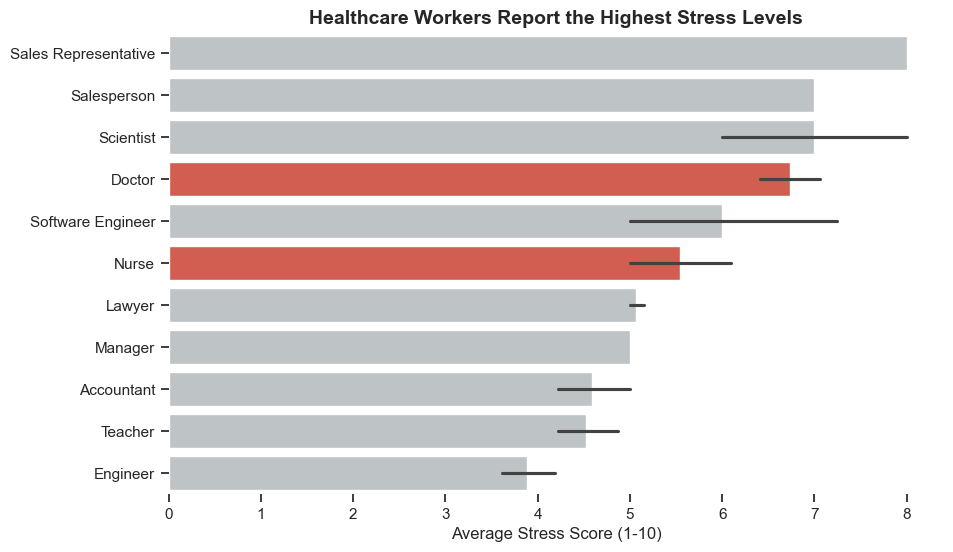

In [18]:

# Relationship: Stress vs. Sleep Hours
# Goal: To show the "Relationship" (Correlation) between stress and sleep length.

plt.figure(figsize=(10, 6))

# Create a helper column for coloring
df['Highlight'] = df['Occupation'].apply(lambda x: 'Healthcare' if x in ['Doctor','Nurse'] else 'Other')

sns.barplot(data=df, x='Stress Level', y='Occupation', order=stress_order,
            hue='Highlight', dodge=False, palette={'Healthcare':'#e74c3c', 'Other':'#bdc3c7'})

plt.title('Healthcare Workers Report the Highest Stress Levels', fontsize=14, fontweight='bold')
plt.xlabel('Average Stress Score (1-10)')
plt.ylabel('')
plt.legend_.remove()  # Optional: remove the legend if no
sns.despine(left=True, bottom=True)
plt.show()

### Interpretation

The results show clear disparities in stress levels across occupations.

Healthcare professionals report the highest average stress levels, significantly exceeding those observed in several other roles.

This suggests that occupational demands and work environments may be strong predictors of stress exposure. Professions with elevated stress may therefore face greater vulnerability to sleep disruption.

# Physical Activity and Sleep Duration: A Multivariable Relationship

Sleep health may be influenced not only by occupation but also by lifestyle behaviors.

This visualization explores the relationship between physical activity level and sleep duration. BMI category is included to examine potential health differences, while stress level is represented by marker size to provide additional context.

The goal is to determine whether higher physical activity is associated with longer sleep duration and whether stress or BMI appear to influence this pattern.

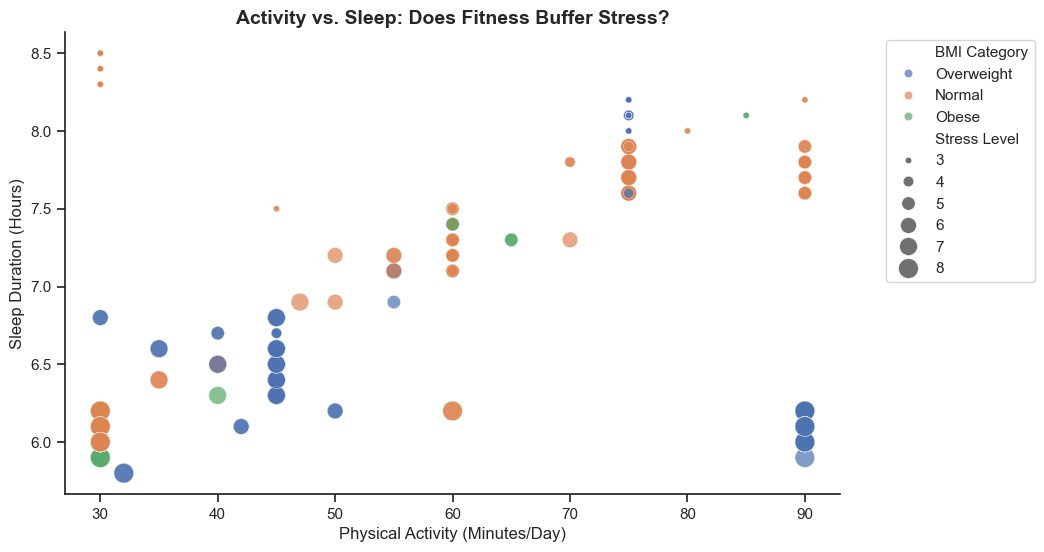

In [22]:
# A graph showing a relationship between physical activity and sleep duration

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Physical Activity Level', y='Sleep Duration', 
                hue='BMI Category', size='Stress Level', sizes=(20, 200), alpha=0.7)

plt.title('Activity vs. Sleep: Does Fitness Buffer Stress?', fontsize=14, fontweight='bold')
plt.xlabel('Physical Activity (Minutes/Day)')
plt.ylabel('Sleep Duration (Hours)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2) # Clean spacing for legend
sns.despine()
plt.show()

### Interpretation

The scatter plot suggests a modest positive relationship between physical activity and sleep duration. Individuals with higher activity levels tend to sleep slightly longer.

However, variation across BMI categories and stress levels indicates that physical activity alone does not fully determine sleep outcomes. Larger markers (representing higher stress levels) appear more concentrated among individuals with shorter sleep duration, suggesting that stress may weaken the positive effect of physical activity.

This implies that while exercise contributes to better sleep, occupational stress may still play a dominant role in sleep disruption.

## Final Takeaway

Sleep quality improves most noticeably within the seven to eight hour range, highlighting an optimal recovery window.  

Healthcare professionals experience the highest stress levels, which may prevent them from consistently reaching this sleep threshold.  

While physical activity has a modest positive effect on sleep duration, it does not fully offset the influence of occupational stress.  

These findings suggest that achieving healthy sleep requires both personal lifestyle strategies and organizational awareness of workplace stress.